# Prévision de la Production d'Énergie Renouvelable dans les Smart Grids
## Mini-Projet Master IA — Apprentissage Supervisé (Régression)

---

**Objectif :** Prédire la production d'énergie renouvelable en Allemagne (solaire + éolien)  
**Dataset :** Données horaires européennes d'énergie (Open Power System Data)  
**Approche :** Régression supervisée avec comparaison de plusieurs modèles de machine learning

---

> **Pourquoi la régression supervisée ?**  
> Nous cherchons à prédire une valeur continue (la production en MWh), à partir de features historiques connues.  
> C'est exactement la définition d'une tâche de régression supervisée : on apprend une fonction f(X) → y  
> où y est une variable numérique continue.

## 1.  Importation des Bibliothèques

In [10]:
# ── Bibliothèques de base ──────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
import os
warnings.filterwarnings('ignore')

# ── Scikit-learn : prétraitement ───────────────────────────────────────────
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# ── Scikit-learn : modèles ─────────────────────────────────────────────────
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR

# ── Scikit-learn : évaluation ──────────────────────────────────────────────
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    median_absolute_error
)
from sklearn.model_selection import TimeSeriesSplit, cross_val_score

# ── Configuration des graphiques ───────────────────────────────────────────
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')
os.makedirs("figures", exist_ok=True)

def sauver_figure(nom_fichier):
    """Sauvegarde la figure courante en haute résolution pour l'article."""
    plt.savefig(os.path.join("figures", nom_fichier), dpi=300, bbox_inches="tight")

COULEUR_PRINCIPALE = '#2ecc71'  # vert pour l'énergie renouvelable

print(" Toutes les bibliothèques importées avec succès.")

 Toutes les bibliothèques importées avec succès.


## 2.  Chargement du Dataset

In [11]:
# ── Chargement du fichier CSV ──────────────────────────────────────────────
# Modifier ce chemin si le fichier CSV se trouve dans un autre dossier.
CHEMIN_FICHIER = 'time_series_60min_singleindex.csv'

df = pd.read_csv(CHEMIN_FICHIER)

print(f" Fichier chargé avec succès.")
print(f"    {df.shape[0]:,} lignes | {df.shape[1]} colonnes")


 Fichier chargé avec succès.
    50,401 lignes | 300 colonnes


## 3.  Exploration Initiale du Dataset

In [12]:
# ── 3.1 Dimensions du dataset ──────────────────────────────────────────────
print("=" * 60)
print(" DIMENSIONS DU DATASET")
print("=" * 60)
print(f"Nombre de lignes    : {df.shape[0]:,}")
print(f"Nombre de colonnes  : {df.shape[1]}")

 DIMENSIONS DU DATASET
Nombre de lignes    : 50,401
Nombre de colonnes  : 300


In [13]:
# ── 3.2 Colonnes disponibles ───────────────────────────────────────────────
print("=" * 60)
print(" TOUTES LES COLONNES")
print("=" * 60)
for i, col in enumerate(df.columns):
    print(f"  [{i:3d}] {col}")

 TOUTES LES COLONNES
  [  0] utc_timestamp
  [  1] cet_cest_timestamp
  [  2] AT_load_actual_entsoe_transparency
  [  3] AT_load_forecast_entsoe_transparency
  [  4] AT_price_day_ahead
  [  5] AT_solar_generation_actual
  [  6] AT_wind_onshore_generation_actual
  [  7] BE_load_actual_entsoe_transparency
  [  8] BE_load_forecast_entsoe_transparency
  [  9] BE_solar_generation_actual
  [ 10] BE_wind_generation_actual
  [ 11] BE_wind_offshore_generation_actual
  [ 12] BE_wind_onshore_generation_actual
  [ 13] BG_load_actual_entsoe_transparency
  [ 14] BG_load_forecast_entsoe_transparency
  [ 15] BG_solar_generation_actual
  [ 16] BG_wind_onshore_generation_actual
  [ 17] CH_load_actual_entsoe_transparency
  [ 18] CH_load_forecast_entsoe_transparency
  [ 19] CH_solar_capacity
  [ 20] CH_solar_generation_actual
  [ 21] CH_wind_onshore_capacity
  [ 22] CH_wind_onshore_generation_actual
  [ 23] CY_load_actual_entsoe_transparency
  [ 24] CY_load_forecast_entsoe_transparency
  [ 25] CY_wind_ons

In [14]:
# ── 3.3 Colonnes allemandes (DE_) ──────────────────────────────────────────
# On identifie toutes les colonnes liées à l'Allemagne (préfixe DE_)
# On exclut les sous-opérateurs (DE_50hertz, DE_amprion, etc.) pour garder
# uniquement les données nationales agrégées
colonnes_de = [
    col for col in df.columns
    if col.startswith('DE_')
    and not any(op in col for op in ['50hertz', 'amprion', 'tennet', 'transnetbw', 'LU'])
]

print("=" * 60)
print(" COLONNES ALLEMANDES (DE_) UTILES")
print("=" * 60)
for col in colonnes_de:
    nb_manquants = df[col].isna().sum()
    pct = nb_manquants / len(df) * 100
    print(f"  {col:<45} | {nb_manquants:6,} manquants ({pct:.1f}%)")

 COLONNES ALLEMANDES (DE_) UTILES
  DE_load_actual_entsoe_transparency            |      1 manquants (0.0%)
  DE_load_forecast_entsoe_transparency          |     25 manquants (0.0%)
  DE_solar_capacity                             |  6,601 manquants (13.1%)
  DE_solar_generation_actual                    |    104 manquants (0.2%)
  DE_solar_profile                              |  6,705 manquants (13.3%)
  DE_wind_capacity                              |  6,601 manquants (13.1%)
  DE_wind_generation_actual                     |     75 manquants (0.1%)
  DE_wind_profile                               |  6,676 manquants (13.2%)
  DE_wind_offshore_capacity                     |  6,601 manquants (13.1%)
  DE_wind_offshore_generation_actual            |     75 manquants (0.1%)
  DE_wind_offshore_profile                      |  6,676 manquants (13.2%)
  DE_wind_onshore_capacity                      |  6,601 manquants (13.1%)
  DE_wind_onshore_generation_actual             |     73 manquants (0.1

In [15]:
# ── 3.4 Valeurs manquantes globales (top 20) ───────────────────────────────
print("=" * 60)
print(" VALEURS MANQUANTES — TOP 20 COLONNES")
print("=" * 60)
manquants = df.isnull().sum()
manquants_pct = (manquants / len(df) * 100).round(2)
resume_manquants = pd.DataFrame({
    'Nb manquants': manquants,
    '% manquants': manquants_pct
}).sort_values('Nb manquants', ascending=False)

print(resume_manquants[resume_manquants['Nb manquants'] > 0].head(20).to_string())

 VALEURS MANQUANTES — TOP 20 COLONNES
                                         Nb manquants  % manquants
HR_solar_generation_actual                      50391        99.98
HR_wind_onshore_generation_actual               50379        99.96
PT_wind_offshore_generation_actual              47509        94.26
PT_wind_generation_actual                       47509        94.26
PL_solar_generation_actual                      46237        91.74
HU_solar_generation_actual                      41436        82.21
SK_wind_onshore_generation_actual               40722        80.80
NO_5_wind_onshore_generation_actual             40132        79.63
NO_1_wind_onshore_generation_actual             35815        71.06
DE_LU_load_forecast_entsoe_transparency         33745        66.95
IE_sem_price_day_ahead                          32886        65.25
DE_LU_load_actual_entsoe_transparency           32877        65.23
DE_LU_solar_generation_actual                   32862        65.20
DE_LU_price_day_ahead   

In [16]:
# ── 3.5 Statistiques descriptives des colonnes DE_ ────────────────────────
print("=" * 60)
print(" STATISTIQUES DESCRIPTIVES — COLONNES ALLEMANDES")
print("=" * 60)
display(df[colonnes_de].describe().round(2))

 STATISTIQUES DESCRIPTIVES — COLONNES ALLEMANDES


,DE_load_actual_entsoe_transparency,DE_load_forecast_entsoe_transparency,DE_solar_capacity,DE_solar_generation_actual,DE_solar_profile,DE_wind_capacity,DE_wind_generation_actual,DE_wind_profile,DE_wind_offshore_capacity,DE_wind_offshore_generation_actual,DE_wind_offshore_profile,DE_wind_onshore_capacity,DE_wind_onshore_generation_actual,DE_wind_onshore_profile
count,50400.00,50376.00,43800.00,50297.00,43696.00,43800.00,50326.00,43725.00,43800.00,50326.00,43725.00,43800.00,50328.00,43727.00
mean,55492.47,54791.38,42378.02,4566.04,0.10,39972.61,11552.23,0.28,3261.02,1970.48,0.57,36711.59,9581.47,0.25
std,10015.43,9496.89,4306.39,6940.27,0.16,7262.79,9076.35,0.21,1359.19,1567.54,0.39,5961.44,7987.85,0.21
min,31307.00,28824.00,37248.00,0.00,0.00,27913.00,135.00,0.00,667.00,0.00,0.00,27246.00,119.00,0.00
25%,47106.00,46987.00,38810.00,0.00,0.00,33737.00,4506.00,0.11,2219.00,586.00,0.21,31519.00,3534.00,0.10
50%,55092.00,54731.50,40941.00,173.00,0.00,39808.00,9015.00,0.22,3115.00,1640.00,0.54,36693.00,7128.50,0.19
75%,64309.25,62877.25,46092.00,7342.00,0.16,47730.00,16113.75,0.39,4486.00,3066.00,0.90,43243.00,13302.25,0.35
max,77549.00,75912.00,50508.00,32947.00,0.69,50452.00,46064.00,1.08,5742.00,6901.00,1.50,44710.00,40752.00,1.09


## 4.  Conversion de la Colonne Temporelle

In [17]:
# ── Détection automatique de la colonne timestamp ─────────────────────────
# On cherche une colonne dont le nom ressemble à un timestamp
noms_timestamp_possibles = ['utc_timestamp', 'timestamp', 'time', 'cet_cest_timestamp', 'date']
colonne_temps = None

for nom in noms_timestamp_possibles:
    if nom in df.columns:
        colonne_temps = nom
        break

# Si aucun nom connu, chercher la première colonne de type objet (chaîne)
if colonne_temps is None:
    for col in df.columns:
        if df[col].dtype == 'object':
            try:
                pd.to_datetime(df[col].iloc[0])
                colonne_temps = col
                break
            except:
                continue

print(f" Colonne temporelle détectée : '{colonne_temps}'")
print(f"   Exemple de valeur : {df[colonne_temps].iloc[0]}")

# ── Conversion en datetime et utilisation comme index ─────────────────────
df[colonne_temps] = pd.to_datetime(df[colonne_temps], utc=True)
df = df.set_index(colonne_temps)
df.index = df.index.tz_localize(None)  # Supprimer le fuseau horaire pour simplifier
df = df.sort_index()  # S'assurer que l'index est trié chronologiquement

print(f"\n Période couverte :")
print(f"   Début : {df.index.min()}")
print(f"   Fin   : {df.index.max()}")
print(f"   Durée : {(df.index.max() - df.index.min()).days} jours")

 Colonne temporelle détectée : 'utc_timestamp'
   Exemple de valeur : 2014-12-31T23:00:00Z

 Période couverte :
   Début : 2014-12-31 23:00:00
   Fin   : 2020-09-30 23:00:00
   Durée : 2100 jours


## 5.  Création de la Variable Cible

In [18]:
# ── Création de DE_renewable_generation ───────────────────────────────────
# Stratégie robuste :
#   1. Utiliser la production solaire réelle.
#   2. Utiliser la production éolienne totale si elle existe.
#   3. Sinon additionner éolien onshore + offshore.
#   4. Conserver NaN seulement si toutes les composantes nécessaires sont absentes.

TARGET = 'DE_renewable_generation'
col_solaire = 'DE_solar_generation_actual'

cols_composantes = [col_solaire]

if 'DE_wind_generation_actual' in df.columns:
    col_eolien = 'DE_wind_generation_actual'
    cols_composantes.append(col_eolien)
    print(' Utilisation de DE_wind_generation_actual (éolien total)')
else:
    col_eolien_on = 'DE_wind_onshore_generation_actual'
    col_eolien_off = 'DE_wind_offshore_generation_actual'
    cols_composantes.extend([col_eolien_on, col_eolien_off])
    print(' DE_wind_generation_actual absent — combinaison onshore + offshore')

# sum(min_count=1) évite de transformer une ligne entièrement manquante en zéro.
df[TARGET] = df[cols_composantes].sum(axis=1, min_count=1)

print(f"Variable cible '{TARGET}' créée.")
print(f"   Valeurs non-nulles : {df[TARGET].notna().sum():,}")
print(f"   Valeurs nulles     : {df[TARGET].isna().sum():,}")
print(f"   Min : {df[TARGET].min():,.0f} MWh")
print(f"   Max : {df[TARGET].max():,.0f} MWh")
print(f"   Moyenne : {df[TARGET].mean():,.0f} MWh")


 Utilisation de DE_wind_generation_actual (éolien total)
Variable cible 'DE_renewable_generation' créée.
   Valeurs non-nulles : 50,328
   Valeurs nulles     : 73
   Min : 312 MWh
   Max : 61,169 MWh
   Moyenne : 16,115 MWh


## 6.  Création des Features Temporelles

In [19]:
# ── Features temporelles dérivées de l'index datetime ────────────────────
# Ces features capturent les cycles naturels de production d'énergie :
# - L'heure du jour (le solaire est nul la nuit)
# - Le mois (l'été produit plus de solaire)
# - Le jour de la semaine (impact sur la demande)

df['heure']     = df.index.hour          # 0–23 : cycle journalier
df['jour']      = df.index.day           # 1–31 : jour du mois
df['mois']      = df.index.month         # 1–12 : cycle saisonnier
df['annee']     = df.index.year          # tendances long terme
df['jour_sem']  = df.index.dayofweek     # 0=lundi … 6=dimanche
df['weekend']   = (df['jour_sem'] >= 5).astype(int)  # 1 si weekend

print(" Features temporelles créées :")
for feat in ['heure', 'jour', 'mois', 'annee', 'jour_sem', 'weekend']:
    print(f"   {feat:<12}  valeurs uniques : {df[feat].nunique()}")

 Features temporelles créées :
   heure         valeurs uniques : 24
   jour          valeurs uniques : 31
   mois          valeurs uniques : 12
   annee         valeurs uniques : 7
   jour_sem      valeurs uniques : 7
   weekend       valeurs uniques : 2


## 7.  Création des Features de Lag (Décalage Temporel)

In [20]:
# ── Features de lag ────────────────────────────────────────────────────────
# Les lags permettent au modèle d'utiliser les valeurs PASSÉES pour prédire
# la valeur FUTURE. C'est la clé du forecasting de séries temporelles.
#
#   lag_1h   = production il y a 1 heure    dépendance court terme
#   lag_24h  = production il y a 24 heures  même heure hier (cycle journalier)
#   lag_168h = production il y a 7 jours    même heure la semaine dernière

TARGET = 'DE_renewable_generation'

df['renewable_lag_1h']   = df[TARGET].shift(1)
df['renewable_lag_24h']  = df[TARGET].shift(24)
df['renewable_lag_168h'] = df[TARGET].shift(168)

print(" Features de lag créées :")
print(f"   renewable_lag_1h   (shift=1)    {df['renewable_lag_1h'].notna().sum():,} valeurs")
print(f"   renewable_lag_24h  (shift=24)   {df['renewable_lag_24h'].notna().sum():,} valeurs")
print(f"   renewable_lag_168h (shift=168)  {df['renewable_lag_168h'].notna().sum():,} valeurs")

 Features de lag créées :
   renewable_lag_1h   (shift=1)    50,327 valeurs
   renewable_lag_24h  (shift=24)   50,304 valeurs
   renewable_lag_168h (shift=168)  50,160 valeurs


## 8. Création des Features de Moyenne Mobile (Rolling)

In [21]:
# ── Moyennes mobiles ───────────────────────────────────────────────────────
# Les moyennes mobiles lissent les fluctuations et capturent les tendances :
#   rolling_24h  = moyenne des 24 dernières heures  tendance journalière
#   rolling_168h = moyenne des 7 derniers jours     tendance hebdomadaire
#
# On utilise .shift(1) AVANT le rolling pour éviter la fuite de données :
# on ne doit pas utiliser la valeur actuelle dans le calcul de la moyenne.

df['renewable_rolling_24h']  = df[TARGET].shift(1).rolling(window=24,  min_periods=12).mean()
df['renewable_rolling_168h'] = df[TARGET].shift(1).rolling(window=168, min_periods=84).mean()

print(" Features rolling créées :")
print(f"   renewable_rolling_24h   {df['renewable_rolling_24h'].notna().sum():,} valeurs")
print(f"   renewable_rolling_168h  {df['renewable_rolling_168h'].notna().sum():,} valeurs")

 Features rolling créées :
   renewable_rolling_24h   50,319 valeurs
   renewable_rolling_168h  50,316 valeurs


## 9.  Sélection Automatique des Features

In [40]:
# ── Sélection intelligente des features ───────────────────────────────────
# On sélectionne :
#   1. Les features temporelles
#   2. Les lags et rolling
#   3. Les colonnes DE_ pertinentes (charge, capacité) — SANS la cible
#      pour éviter la fuite de données (data leakage)

# Features temporelles
features_temps = ['heure', 'jour', 'mois', 'annee', 'jour_sem', 'weekend']

# Features de lag et rolling
features_lag_rolling = [
    'renewable_lag_1h', 'renewable_lag_24h', 'renewable_lag_168h',
    'renewable_rolling_24h', 'renewable_rolling_168h'
]

# Colonnes DE_ utiles comme features contextuelles
# On exclut : la cible elle-même, les sous-opérateurs, les colonnes de production
# (elles contiendraient la cible de façon déguisée  data leakage)
mots_interdits = [
    TARGET,           # cible directe  fuite garantie
    'solar_generation_actual',    # composante directe de la cible
    'wind_generation_actual',     # composante directe de la cible
    'wind_onshore_generation_actual',
    'wind_offshore_generation_actual',
    'profile',        # dérivé de la génération
    '50hertz', 'amprion', 'tennet', 'transnetbw', 'LU',  # sous-opérateurs
]

features_de = [
    col for col in colonnes_de
    if col != TARGET
    and not any(m in col for m in mots_interdits)
    and df[col].notna().sum() > len(df) * 0.5  # au moins 50% de données
]

# Liste finale de toutes les features
TOUTES_FEATURES = features_temps + features_lag_rolling + features_de

print("=" * 60)
print(" FEATURES SÉLECTIONNÉES")
print("=" * 60)
print(f"\n Features temporelles ({len(features_temps)}) :")
for f in features_temps: print(f"    {f}")

print(f"\n Lag & Rolling ({len(features_lag_rolling)}) :")
for f in features_lag_rolling: print(f"    {f}")

print(f"\n Colonnes DE_ contextuelles ({len(features_de)}) :")
for f in features_de: print(f"    {f}")

print(f"\n Total features : {len(TOUTES_FEATURES)}")
print(f" Variable cible : {TARGET}")

 FEATURES SÉLECTIONNÉES

 Features temporelles (6) :
    heure
    jour
    mois
    annee
    jour_sem
    weekend

 Lag & Rolling (5) :
    renewable_lag_1h
    renewable_lag_24h
    renewable_lag_168h
    renewable_rolling_24h
    renewable_rolling_168h

 Colonnes DE_ contextuelles (6) :
    DE_load_actual_entsoe_transparency
    DE_load_forecast_entsoe_transparency
    DE_solar_capacity
    DE_wind_capacity
    DE_wind_offshore_capacity
    DE_wind_onshore_capacity

 Total features : 17
 Variable cible : DE_renewable_generation


## 10. Gestion des Valeurs Manquantes

In [23]:
# ── Suppression des lignes avec des valeurs manquantes critiques ──────────
# Après création des lags/rolling, les premières lignes ont des NaN inévitables.
# On supprime les lignes où la CIBLE est manquante (impossible à entraîner).
# Pour les features, on utilisera SimpleImputer dans les pipelines.

nb_avant = len(df)

# Supprimer les lignes sans cible
df = df.dropna(subset=[TARGET])

# Supprimer les lignes sans lag_1h (le lag le plus critique)
df = df.dropna(subset=['renewable_lag_1h'])

nb_apres = len(df)
print(f" Nettoyage terminé :")
print(f"   Avant nettoyage : {nb_avant:,} lignes")
print(f"   Après nettoyage : {nb_apres:,} lignes")
print(f"   Lignes supprimées : {nb_avant - nb_apres:,}")

# Vérification des NaN restants dans les features sélectionnées
print(f"\n NaN restants dans les features :")
for feat in TOUTES_FEATURES:
    n_nan = df[feat].isna().sum()
    if n_nan > 0:
        print(f"   {feat}: {n_nan:,} NaN  sera imputé par la médiane dans le pipeline")

 Nettoyage terminé :
   Avant nettoyage : 50,401 lignes
   Après nettoyage : 50,324 lignes
   Lignes supprimées : 77

 NaN restants dans les features :
   renewable_lag_24h: 92 NaN  sera imputé par la médiane dans le pipeline
   renewable_lag_168h: 239 NaN  sera imputé par la médiane dans le pipeline
   renewable_rolling_24h: 44 NaN  sera imputé par la médiane dans le pipeline
   renewable_rolling_168h: 83 NaN  sera imputé par la médiane dans le pipeline
   DE_load_forecast_entsoe_transparency: 24 NaN  sera imputé par la médiane dans le pipeline
   DE_solar_capacity: 6,601 NaN  sera imputé par la médiane dans le pipeline
   DE_wind_capacity: 6,601 NaN  sera imputé par la médiane dans le pipeline
   DE_wind_offshore_capacity: 6,601 NaN  sera imputé par la médiane dans le pipeline
   DE_wind_onshore_capacity: 6,601 NaN  sera imputé par la médiane dans le pipeline


## 11.  Analyse Exploratoire des Données (EDA)

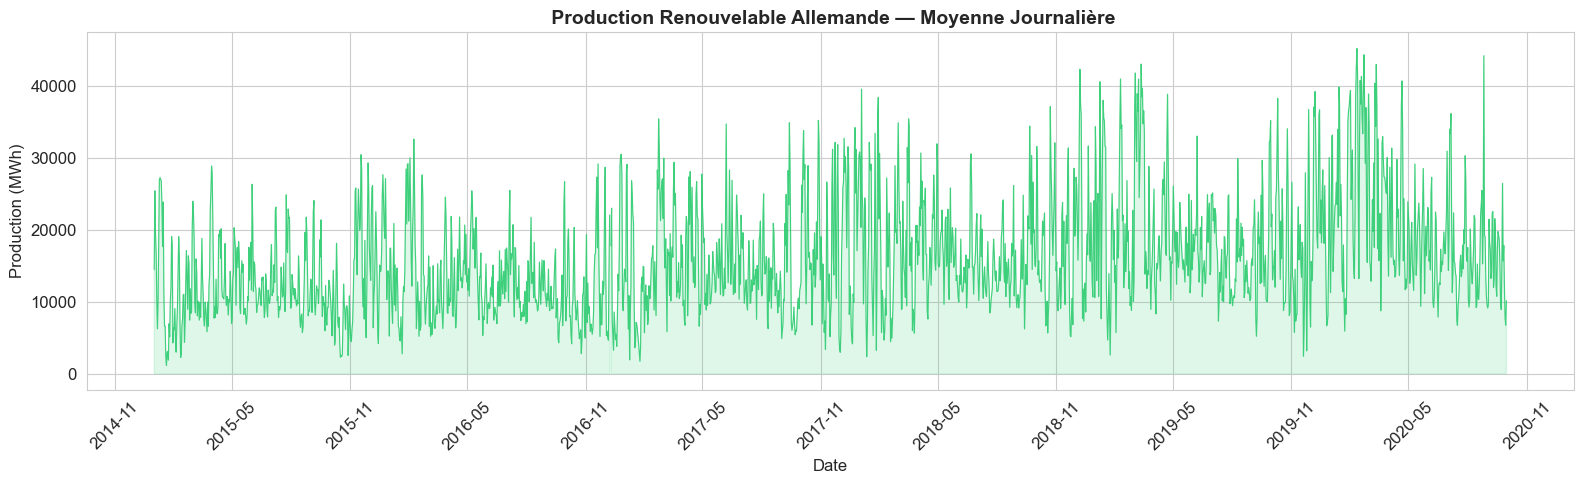

In [24]:
# ── 11.1 Série temporelle de la production renouvelable ───────────────────
fig, ax = plt.subplots(figsize=(16, 5))

# Rééchantillonner à la journée pour une lecture plus claire
serie_journaliere = df[TARGET].resample('D').mean()
ax.plot(serie_journaliere.index, serie_journaliere.values,
        color=COULEUR_PRINCIPALE, linewidth=0.8, alpha=0.9)
ax.fill_between(serie_journaliere.index, serie_journaliere.values,
                alpha=0.15, color=COULEUR_PRINCIPALE)

ax.set_title(' Production Renouvelable Allemande — Moyenne Journalière', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Production (MWh)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.xticks(rotation=45)
plt.tight_layout()
sauver_figure('figure_01_production_moyenne_journaliere.png')
plt.show()

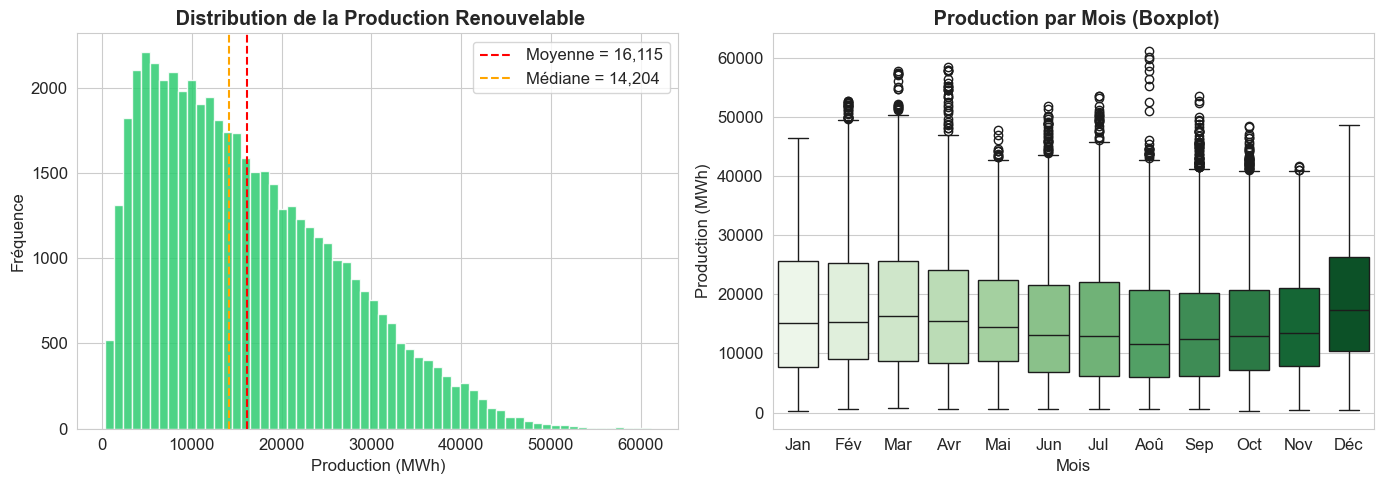

In [25]:
# ── 11.2 Distribution de la variable cible ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogramme
axes[0].hist(df[TARGET].dropna(), bins=60, color=COULEUR_PRINCIPALE,
             edgecolor='white', alpha=0.85)
axes[0].set_title(' Distribution de la Production Renouvelable', fontweight='bold')
axes[0].set_xlabel('Production (MWh)')
axes[0].set_ylabel('Fréquence')
axes[0].axvline(df[TARGET].mean(), color='red', linestyle='--', label=f"Moyenne = {df[TARGET].mean():,.0f}")
axes[0].axvline(df[TARGET].median(), color='orange', linestyle='--', label=f"Médiane = {df[TARGET].median():,.0f}")
axes[0].legend()

# Boxplot par mois
df_eda = df[[TARGET, 'mois']].copy()
df_eda['Mois'] = df_eda['mois'].map({
    1:'Jan', 2:'Fév', 3:'Mar', 4:'Avr', 5:'Mai', 6:'Jun',
    7:'Jul', 8:'Aoû', 9:'Sep', 10:'Oct', 11:'Nov', 12:'Déc'
})
ordre_mois = ['Jan', 'Fév', 'Mar', 'Avr', 'Mai', 'Jun',
               'Jul', 'Aoû', 'Sep', 'Oct', 'Nov', 'Déc']

sns.boxplot(data=df_eda, x='Mois', y=TARGET, order=ordre_mois,
            palette='Greens', ax=axes[1])
axes[1].set_title(' Production par Mois (Boxplot)', fontweight='bold')
axes[1].set_xlabel('Mois')
axes[1].set_ylabel('Production (MWh)')

plt.tight_layout()
sauver_figure('figure_02_distribution_boxplot.png')
plt.show()

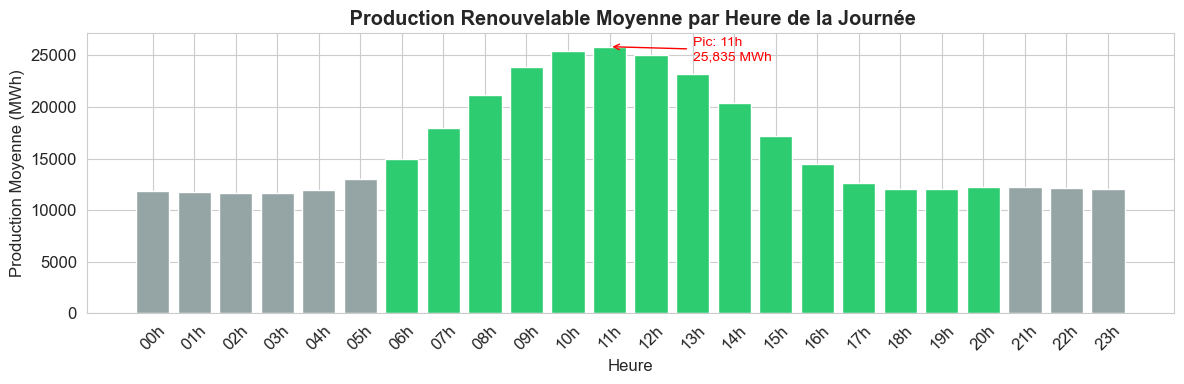

In [26]:
# ── 11.3 Profil horaire moyen ─────────────────────────────────────────────
profil_horaire = df.groupby('heure')[TARGET].mean()

fig, ax = plt.subplots(figsize=(12, 4))
bars = ax.bar(profil_horaire.index, profil_horaire.values,
              color=[COULEUR_PRINCIPALE if 6 <= h <= 20 else '#95a5a6' for h in profil_horaire.index],
              edgecolor='white')
ax.set_title(' Production Renouvelable Moyenne par Heure de la Journée', fontweight='bold')
ax.set_xlabel('Heure')
ax.set_ylabel('Production Moyenne (MWh)')
ax.set_xticks(range(0, 24))
ax.set_xticklabels([f'{h:02d}h' for h in range(24)], rotation=45)
# Annotation du pic
heure_pic = profil_horaire.idxmax()
ax.annotate(f'Pic: {heure_pic:02d}h\n{profil_horaire[heure_pic]:,.0f} MWh',
            xy=(heure_pic, profil_horaire[heure_pic]),
            xytext=(heure_pic + 2, profil_horaire[heure_pic] * 0.95),
            arrowprops=dict(arrowstyle='->', color='red'),
            fontsize=10, color='red')
plt.tight_layout()
sauver_figure('figure_03_profil_horaire.png')
plt.show()

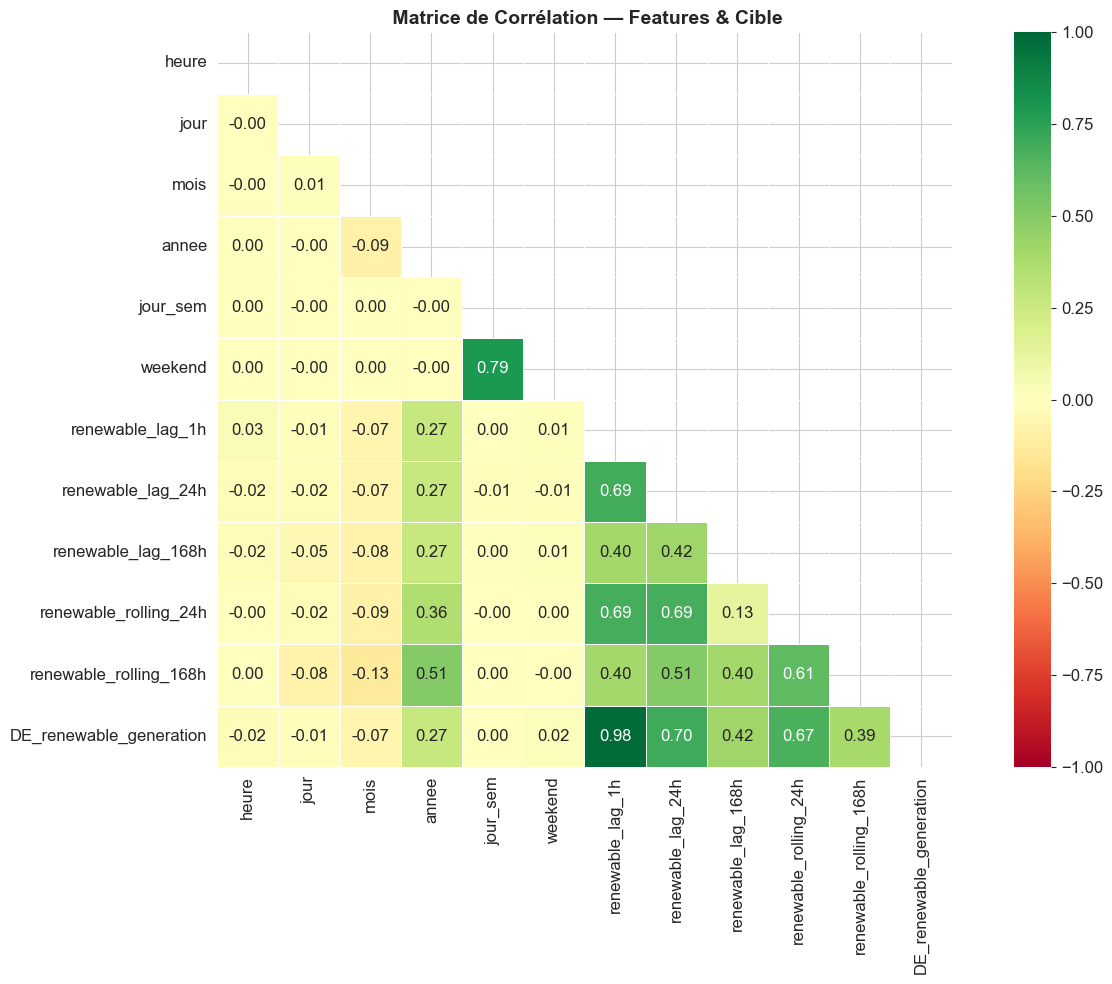


 Corrélation avec la cible (DE_renewable_generation) :
   renewable_lag_1h                    +███████████████████  +0.978
   renewable_lag_24h                   +█████████████        +0.700
   renewable_rolling_24h               +█████████████        +0.671
   renewable_lag_168h                  +████████             +0.419
   renewable_rolling_168h              +███████              +0.395
   annee                               +█████                +0.267
   mois                                -█                    -0.068
   heure                               -                     -0.025
   weekend                             +                     +0.016
   jour                                -                     -0.015
   jour_sem                            +                     +0.003


In [27]:
# ── 11.4 Matrice de corrélation des features ──────────────────────────────
# On sélectionne un sous-ensemble représentatif pour la lisibilité
cols_corr = features_temps + features_lag_rolling + [TARGET]
corr_matrix = df[cols_corr].corr()

fig, ax = plt.subplots(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # masque triangle sup
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True, fmt='.2f', cmap='RdYlGn',
    center=0, vmin=-1, vmax=1,
    square=True, linewidths=0.5,
    ax=ax
)
ax.set_title(' Matrice de Corrélation — Features & Cible', fontsize=14, fontweight='bold')
plt.tight_layout()
sauver_figure('figure_04_matrice_correlation.png')
plt.show()

# Afficher la corrélation de chaque feature avec la cible
print("\n Corrélation avec la cible (DE_renewable_generation) :")
corr_cible = corr_matrix[TARGET].drop(TARGET).sort_values(key=abs, ascending=False)
for feat, val in corr_cible.items():
    barre = '█' * int(abs(val) * 20)
    signe = '+' if val > 0 else '-'
    print(f"   {feat:<35} {signe}{barre:<20} {val:+.3f}")

## 12.  Division Chronologique Train / Test

> **Pourquoi une division chronologique et non aléatoire ?**  
> Dans une série temporelle, les données sont ordonnées dans le temps.  
> Une division aléatoire "contaminerait" l'entraînement avec des données futures,  
> ce qui est impossible en pratique réelle (on ne peut pas connaître le futur).  
> La division chronologique simule fidèlement la réalité : on entraîne sur le passé, on prédit le futur.

In [28]:
# ── Division chronologique : avant 2020  train, à partir de 2020  test ──
annees_disponibles = df.index.year.unique()
print(f"Années disponibles dans le dataset : {sorted(annees_disponibles)}")

if 2020 in annees_disponibles:
    # Méthode principale : split à l'année 2020
    df_train = df[df.index.year < 2020]
    df_test  = df[df.index.year >= 2020]
    print(" Split chronologique : train < 2020 | test >= 2020")
else:
    # Méthode de secours : 80% / 20% chronologique
    seuil = int(len(df) * 0.80)
    df_train = df.iloc[:seuil]
    df_test  = df.iloc[seuil:]
    print(" 2020 absent — split 80/20 chronologique appliqué")

# Préparation des matrices X et y
X_train = df_train[TOUTES_FEATURES]
y_train = df_train[TARGET]
X_test  = df_test[TOUTES_FEATURES]
y_test  = df_test[TARGET]

print(f"\n Dimensions après split :")
print(f"   Train : {X_train.shape[0]:>8,} lignes | {X_train.shape[1]} features")
print(f"   Test  : {X_test.shape[0]:>8,} lignes | {X_test.shape[1]} features")
print(f"   Ratio train/total : {len(X_train)/len(df)*100:.1f}%")

print(f"\n Période d'entraînement : {df_train.index.min().date()}  {df_train.index.max().date()}")
print(f" Période de test        : {df_test.index.min().date()}   {df_test.index.max().date()}")

Années disponibles dans le dataset : [2015, 2016, 2017, 2018, 2019, 2020]
 Split chronologique : train < 2020 | test >= 2020

 Dimensions après split :
   Train :   43,748 lignes | 17 features
   Test  :    6,576 lignes | 17 features
   Ratio train/total : 86.9%

 Période d'entraînement : 2015-01-01  2019-12-31
 Période de test        : 2020-01-01   2020-09-30


## 13 & 14.  Entraînement des Modèles de Régression

In [29]:
# ── Définition des modèles avec leurs pipelines ───────────────────────────
# Pipeline = séquence d'étapes appliquées en ordre :
#   1. Imputation des NaN (médiane)
#   2. Normalisation StandardScaler (seulement pour les modèles linéaires/SVM)
#   3. Le modèle lui-même

# Imputation des valeurs manquantes (médiane = robuste aux outliers)
imputeur = SimpleImputer(strategy='median')

modeles = {
    # ── Modèles linéaires : nécessitent normalisation ──────────────────────
    'Régression Linéaire': Pipeline([
        ('imputation', imputeur),
        ('normalisation', StandardScaler()),
        ('modele', LinearRegression())
    ]),

    'Ridge Regression': Pipeline([
        ('imputation', imputeur),
        ('normalisation', StandardScaler()),
        ('modele', Ridge(alpha=1.0))
        # alpha=1.0  régularisation L2 pour éviter le surapprentissage
    ]),

    # ── Modèles ensemblistes : pas besoin de normalisation ─────────────────
    'Random Forest': Pipeline([
        ('imputation', imputeur),
        # Pas de StandardScaler : les arbres sont invariants à l'échelle
        ('modele', RandomForestRegressor(
            n_estimators=100,
            max_depth=20,
            min_samples_leaf=5,
            n_jobs=-1,
            random_state=42
        ))
    ]),

    'Gradient Boosting': Pipeline([
        ('imputation', imputeur),
        ('modele', GradientBoostingRegressor(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=5,
            subsample=0.8,
            random_state=42
        ))
    ]),

    # ── SVR : très sensible à l'échelle  normalisation obligatoire ────────
    'SVR': Pipeline([
        ('imputation', imputeur),
        ('normalisation', StandardScaler()),  # INDISPENSABLE pour SVR
        ('modele', SVR(
            kernel='rbf',
            C=100,
            epsilon=0.1
        ))
    ]),
}

print(" Modèles définis :")
for nom in modeles:
    etapes = [e[0] for e in modeles[nom].steps]
    print(f"   {nom:<25}  pipeline : {'  '.join(etapes)}")

 Modèles définis :
   Régression Linéaire        pipeline : imputation  normalisation  modele
   Ridge Regression           pipeline : imputation  normalisation  modele
   Random Forest              pipeline : imputation  modele
   Gradient Boosting          pipeline : imputation  modele
   SVR                        pipeline : imputation  normalisation  modele


In [30]:
# ── Entraînement de tous les modèles ──────────────────────────────────────
import time

resultats = {}       # stocke les métriques
predictions = {}     # stocke les prédictions y_pred
modeles_entraines = {}  # stocke les modèles entraînés

def calculer_mape(y_vrai, y_pred):
    """MAPE : Mean Absolute Percentage Error. Exclut les zéros pour éviter division par 0."""
    masque = y_vrai != 0
    return np.mean(np.abs((y_vrai[masque] - y_pred[masque]) / y_vrai[masque])) * 100

print(" Entraînement des modèles en cours...")
print("=" * 70)

for nom, pipeline in modeles.items():
    print(f"\n {nom}...", end=' ', flush=True)
    debut = time.time()

    # Entraînement
    pipeline.fit(X_train, y_train)

    # Prédiction sur le jeu de test
    y_pred = pipeline.predict(X_test)

    duree = time.time() - debut

    # Calcul des métriques
    mae   = mean_absolute_error(y_test, y_pred)
    mse   = mean_squared_error(y_test, y_pred)
    rmse  = np.sqrt(mse)
    r2    = r2_score(y_test, y_pred)
    mape  = calculer_mape(y_test.values, y_pred)
    medae = median_absolute_error(y_test, y_pred)

    resultats[nom] = {
        'MAE':   mae,
        'MSE':   mse,
        'RMSE':  rmse,
        'R²':    r2,
        'MAPE':  mape,
        'MedAE': medae
    }
    predictions[nom] = y_pred
    modeles_entraines[nom] = pipeline

    print(f" ({duree:.1f}s) | R²={r2:.4f} | RMSE={rmse:,.0f} | MAE={mae:,.0f}")

print("\n" + "=" * 70)
print(" Tous les modèles ont été entraînés avec succès !")

 Entraînement des modèles en cours...

 Régression Linéaire...  (0.2s) | R²=0.9560 | RMSE=2,582 | MAE=1,992

 Ridge Regression...  (0.2s) | R²=0.9561 | RMSE=2,581 | MAE=1,991

 Random Forest...  (51.1s) | R²=0.9853 | RMSE=1,491 | MAE=1,080

 Gradient Boosting...  (110.4s) | R²=0.9849 | RMSE=1,516 | MAE=1,099

 SVR...  (256.4s) | R²=0.8331 | RMSE=5,031 | MAE=3,602

 Tous les modèles ont été entraînés avec succès !


In [31]:
# ── Baseline naïve : persistance ───────────────────────────────────────────
# Ce benchmark est indispensable en séries temporelles :
# prédire la production future par la dernière valeur connue (lag 1h).

nom_baseline = 'Baseline Persistance'
y_pred_persistence = X_test['renewable_lag_1h'].copy()
y_pred_persistence = y_pred_persistence.fillna(X_train['renewable_lag_1h'].median()).values

mae   = mean_absolute_error(y_test, y_pred_persistence)
mse   = mean_squared_error(y_test, y_pred_persistence)
rmse  = np.sqrt(mse)
r2    = r2_score(y_test, y_pred_persistence)
mape  = calculer_mape(y_test.values, y_pred_persistence)
medae = median_absolute_error(y_test, y_pred_persistence)

resultats[nom_baseline] = {
    'MAE': mae,
    'MSE': mse,
    'RMSE': rmse,
    'R²': r2,
    'MAPE': mape,
    'MedAE': medae
}
predictions[nom_baseline] = y_pred_persistence

print(f"Baseline Persistance | R²={r2:.4f} | RMSE={rmse:,.0f} | MAE={mae:,.0f} | MAPE={mape:.2f}%")


Baseline Persistance | R²=0.9508 | RMSE=2,732 | MAE=1,975 | MAPE=12.84%


## 15 & 16.  Évaluation et Tableau de Comparaison

In [32]:
# ── Tableau de comparaison des métriques ──────────────────────────────────
tableau = pd.DataFrame(resultats).T
# Tri principal : R² décroissant
tableau = tableau.sort_values('R²', ascending=False)

# Formater le tableau pour l'affichage
tableau_affichage = tableau.copy()
tableau_affichage['MAE']   = tableau_affichage['MAE'].map('{:,.0f}'.format)
tableau_affichage['MSE']   = tableau_affichage['MSE'].map('{:,.0f}'.format)
tableau_affichage['RMSE']  = tableau_affichage['RMSE'].map('{:,.0f}'.format)
tableau_affichage['R²']    = tableau_affichage['R²'].map('{:.4f}'.format)
tableau_affichage['MAPE']  = tableau_affichage['MAPE'].map('{:.2f}%'.format)
tableau_affichage['MedAE'] = tableau_affichage['MedAE'].map('{:,.0f}'.format)

print('=' * 80)
print('TABLEAU DE COMPARAISON DES MODÈLES (trié par R² décroissant)')
print('=' * 80)
print(tableau_affichage.to_string())
print('=' * 80)

# Identifier le meilleur modèle ML, en gardant la baseline séparée.
modeles_ml = [m for m in tableau.index if m != 'Baseline Persistance']
MEILLEUR_MODELE = tableau.loc[modeles_ml, 'R²'].idxmax()

print(f"MEILLEUR MODÈLE ML : {MEILLEUR_MODELE}")
print(f"   R²   = {tableau.loc[MEILLEUR_MODELE, 'R²']:.4f}")
print(f"   RMSE = {tableau.loc[MEILLEUR_MODELE, 'RMSE']:,.0f} MWh")
print(f"   MAE  = {tableau.loc[MEILLEUR_MODELE, 'MAE']:,.0f} MWh")

if 'Baseline Persistance' in tableau.index:
    print(f"Baseline Persistance : R²={tableau.loc['Baseline Persistance','R²']:.4f}, "
          f"RMSE={tableau.loc['Baseline Persistance','RMSE']:,.0f} MWh, "
          f"MAPE={tableau.loc['Baseline Persistance','MAPE']:.2f}%")


TABLEAU DE COMPARAISON DES MODÈLES (trié par R² décroissant)
                        MAE         MSE   RMSE      R²    MAPE  MedAE
Random Forest         1,080   2,222,718  1,491  0.9853   7.12%    783
Gradient Boosting     1,099   2,297,865  1,516  0.9849   7.42%    790
Ridge Regression      1,991   6,661,796  2,581  0.9561  14.05%  1,569
Régression Linéaire   1,992   6,667,854  2,582  0.9560  14.05%  1,571
Baseline Persistance  1,975   7,463,777  2,732  0.9508  12.84%  1,296
SVR                   3,602  25,312,460  5,031  0.8331  28.08%  2,705
MEILLEUR MODÈLE ML : Random Forest
   R²   = 0.9853
   RMSE = 1,491 MWh
   MAE  = 1,080 MWh
Baseline Persistance : R²=0.9508, RMSE=2,732 MWh, MAPE=12.84%


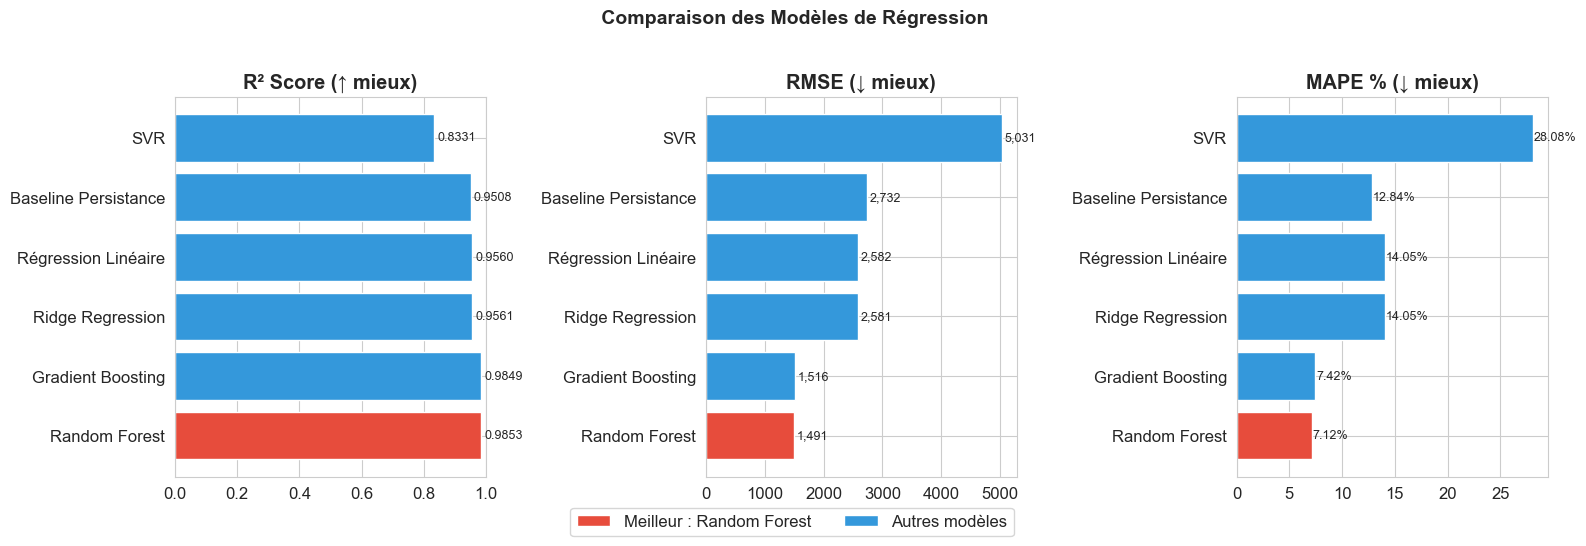

In [33]:
# ── Visualisation comparative des métriques ───────────────────────────────
noms_modeles = list(tableau.index)
couleurs = ['#e74c3c' if nom == MEILLEUR_MODELE else '#3498db' for nom in noms_modeles]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# R² (plus élevé = mieux)
bars0 = axes[0].barh(noms_modeles, tableau.loc[noms_modeles, 'R²'], color=couleurs)
axes[0].set_title('R² Score (↑ mieux)', fontweight='bold')
axes[0].set_xlim(0, 1)
for bar, val in zip(bars0, tableau.loc[noms_modeles, 'R²']):
    axes[0].text(val + 0.01, bar.get_y() + bar.get_height()/2,
                 f'{val:.4f}', va='center', fontsize=9)

# RMSE (plus bas = mieux)
bars1 = axes[1].barh(noms_modeles, tableau.loc[noms_modeles, 'RMSE'], color=couleurs)
axes[1].set_title('RMSE (↓ mieux)', fontweight='bold')
for bar, val in zip(bars1, tableau.loc[noms_modeles, 'RMSE']):
    axes[1].text(val + tableau['RMSE'].max()*0.01, bar.get_y() + bar.get_height()/2,
                 f'{val:,.0f}', va='center', fontsize=9)

# MAPE (plus bas = mieux)
bars2 = axes[2].barh(noms_modeles, tableau.loc[noms_modeles, 'MAPE'], color=couleurs)
axes[2].set_title('MAPE % (↓ mieux)', fontweight='bold')
for bar, val in zip(bars2, tableau.loc[noms_modeles, 'MAPE']):
    axes[2].text(val + 0.1, bar.get_y() + bar.get_height()/2,
                 f'{val:.2f}%', va='center', fontsize=9)

# Légende
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#e74c3c', label=f'Meilleur : {MEILLEUR_MODELE}'),
    Patch(facecolor='#3498db', label='Autres modèles')
]
fig.legend(handles=legend_elements, loc='lower center', ncol=2, bbox_to_anchor=(0.5, -0.05))

plt.suptitle(' Comparaison des Modèles de Régression', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
sauver_figure('figure_05_comparaison_modeles.png')
plt.show()

## 17.  Visualisation du Meilleur Modèle

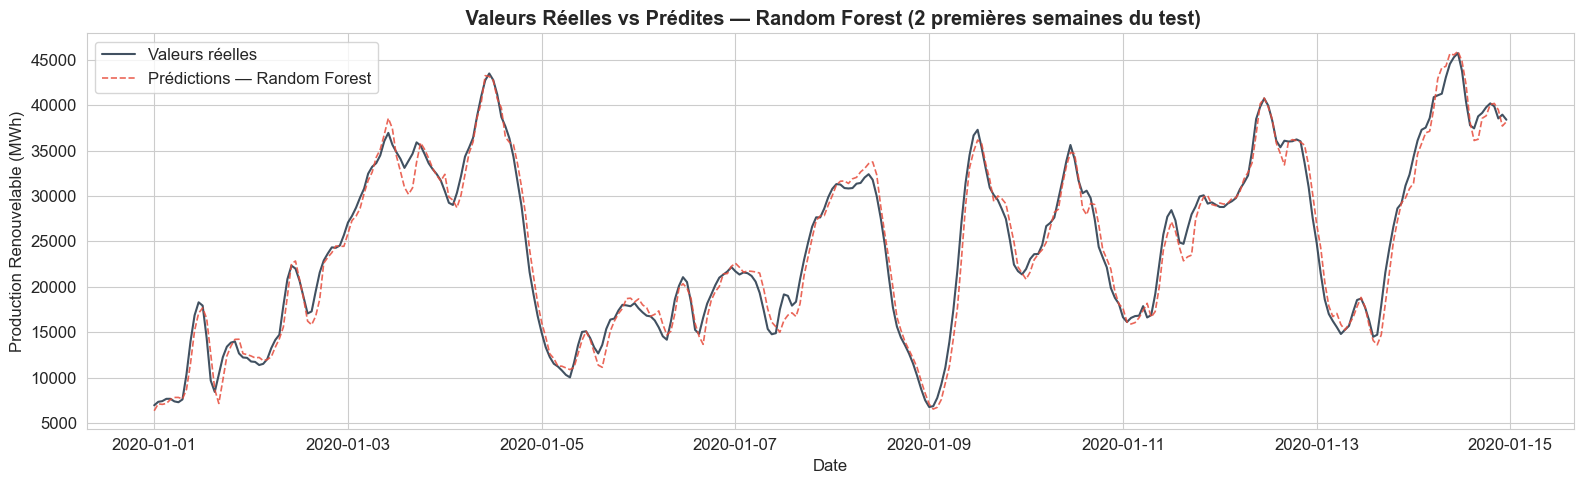

In [34]:
# ── 17.1 Valeurs réelles vs prédites ──────────────────────────────────────
y_pred_best = predictions[MEILLEUR_MODELE]

# On affiche un sous-ensemble pour la lisibilité (2 semaines)
n_affiche = min(24 * 14, len(y_test))
idx_affiche = y_test.index[:n_affiche]

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(idx_affiche, y_test.values[:n_affiche],
        label='Valeurs réelles', color='#2c3e50', linewidth=1.5, alpha=0.9)
ax.plot(idx_affiche, y_pred_best[:n_affiche],
        label=f'Prédictions — {MEILLEUR_MODELE}',
        color='#e74c3c', linewidth=1.2, alpha=0.85, linestyle='--')

ax.set_title(f' Valeurs Réelles vs Prédites — {MEILLEUR_MODELE} (2 premières semaines du test)',
             fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Production Renouvelable (MWh)')
ax.legend()
plt.tight_layout()
sauver_figure('figure_06_valeurs_reelles_vs_predites.png')
plt.show()

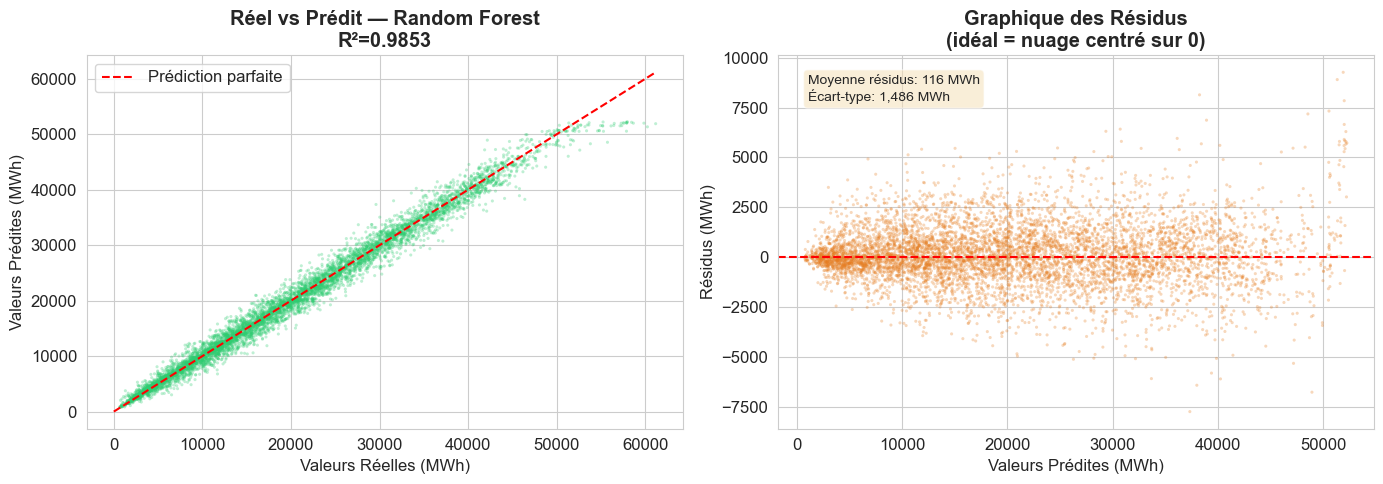

In [35]:
# ── 17.2 Scatter plot réel vs prédit ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter : réel vs prédit (idéal = diagonale parfaite)
axes[0].scatter(y_test.values, y_pred_best, alpha=0.3, s=5,
                color=COULEUR_PRINCIPALE, edgecolors='none')
val_max = max(y_test.max(), y_pred_best.max())
axes[0].plot([0, val_max], [0, val_max], 'r--', linewidth=1.5, label='Prédiction parfaite')
axes[0].set_xlabel('Valeurs Réelles (MWh)')
axes[0].set_ylabel('Valeurs Prédites (MWh)')
axes[0].set_title(f'Réel vs Prédit — {MEILLEUR_MODELE}\nR²={tableau.loc[MEILLEUR_MODELE,"R²"]:.4f}', fontweight='bold')
axes[0].legend()

# Résidus
residus = y_test.values - y_pred_best
axes[1].scatter(y_pred_best, residus, alpha=0.3, s=5,
                color='#e67e22', edgecolors='none')
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Valeurs Prédites (MWh)')
axes[1].set_ylabel('Résidus (MWh)')
axes[1].set_title(f'Graphique des Résidus\n(idéal = nuage centré sur 0)', fontweight='bold')

# Annotation des stats des résidus
axes[1].text(0.05, 0.95, f'Moyenne résidus: {residus.mean():,.0f} MWh\nÉcart-type: {residus.std():,.0f} MWh',
             transform=axes[1].transAxes, fontsize=10,
             verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
sauver_figure('figure_07_reel_predit_residus.png')
plt.show()

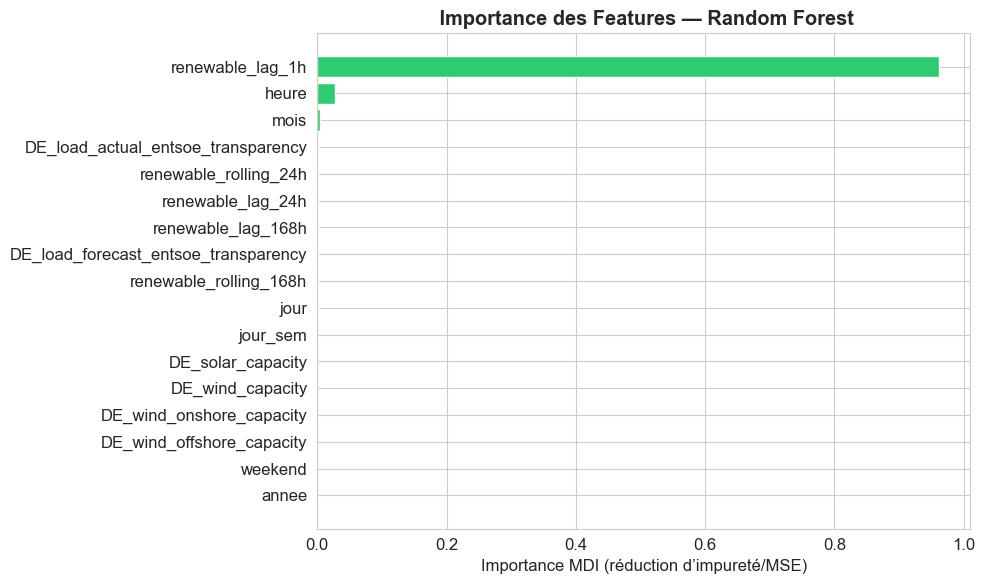


 Top 5 features les plus importantes :
   renewable_lag_1h                         ████████████████████████████████████████████████████████████████████████████████████████████████ 96.19%
   heure                                    ██ 2.70%
   mois                                      0.38%
   DE_load_actual_entsoe_transparency        0.19%
   renewable_rolling_24h                     0.12%


In [36]:
# ── 17.3 Importance des features (si le modèle le supporte) ───────────────
modele_best = modeles_entraines[MEILLEUR_MODELE]

# Récupérer le dernier estimateur du pipeline
estimateur = modele_best.named_steps['modele']

if hasattr(estimateur, 'feature_importances_'):
    importances = estimateur.feature_importances_
    df_imp = pd.DataFrame({
        'Feature': TOUTES_FEATURES,
        'Importance': importances
    }).sort_values('Importance', ascending=True)

    fig, ax = plt.subplots(figsize=(10, max(6, len(TOUTES_FEATURES) * 0.35)))
    colors_imp = [COULEUR_PRINCIPALE if imp >= df_imp['Importance'].quantile(0.75)
                  else '#95a5a6' for imp in df_imp['Importance']]
    ax.barh(df_imp['Feature'], df_imp['Importance'], color=colors_imp)
    ax.set_title(f' Importance des Features — {MEILLEUR_MODELE}', fontweight='bold')
    ax.set_xlabel('Importance MDI (réduction d’impureté/MSE)')
    plt.tight_layout()
    sauver_figure('figure_08_importance_features.png')
    plt.show()

    print("\n Top 5 features les plus importantes :")
    for _, row in df_imp.tail(5).iloc[::-1].iterrows():
        barre = '█' * int(row['Importance'] * 100)
        print(f"   {row['Feature']:<40} {barre} {row['Importance']*100:.2f}%")

elif hasattr(estimateur, 'coef_'):
    # Pour les modèles linéaires : afficher les coefficients
    coefs = np.abs(estimateur.coef_)
    df_coef = pd.DataFrame({'Feature': TOUTES_FEATURES, 'Coefficient': coefs})
    df_coef = df_coef.sort_values('Coefficient', ascending=True)

    fig, ax = plt.subplots(figsize=(10, max(6, len(TOUTES_FEATURES) * 0.35)))
    ax.barh(df_coef['Feature'], df_coef['Coefficient'], color=COULEUR_PRINCIPALE)
    ax.set_title(f' Coefficients (valeur absolue) — {MEILLEUR_MODELE}', fontweight='bold')
    ax.set_xlabel('|Coefficient|')
    plt.tight_layout()
    sauver_figure('figure_08_importance_features.png')
    plt.show()
else:
    print(f"ℹ️ Le modèle {MEILLEUR_MODELE} ne fournit pas nativement l'importance des features.")

## 18. Validation Croisée TimeSeriesSplit



In [37]:
# ── Validation croisée sur les données d'entraînement uniquement ──────────
tscv = TimeSeriesSplit(n_splits=5)

print("=" * 70)
print(" VALIDATION CROISÉE TEMPORELLE (TimeSeriesSplit, 5 folds)")
print("=" * 70)

# On évalue uniquement les 3 modèles principaux pour limiter le temps de calcul
modeles_cv = ['Régression Linéaire', 'Random Forest', 'Gradient Boosting']

resultats_cv = {}

for nom in modeles_cv:
    pipeline = modeles_entraines[nom]
    scores_r2 = []
    scores_rmse = []

    for fold, (idx_train, idx_val) in enumerate(tscv.split(X_train)):
        X_tr, X_val = X_train.iloc[idx_train], X_train.iloc[idx_val]
        y_tr, y_val = y_train.iloc[idx_train], y_train.iloc[idx_val]

        # Recréer et entraîner le pipeline sur ce fold
        from sklearn.base import clone
        pip_clone = clone(pipeline)
        pip_clone.fit(X_tr, y_tr)
        y_val_pred = pip_clone.predict(X_val)

        scores_r2.append(r2_score(y_val, y_val_pred))
        scores_rmse.append(np.sqrt(mean_squared_error(y_val, y_val_pred)))

    resultats_cv[nom] = {
        'R² moyen':     np.mean(scores_r2),
        'R² std':       np.std(scores_r2),
        'RMSE moyen':   np.mean(scores_rmse),
        'RMSE std':     np.std(scores_rmse)
    }

    print(f"\n  {nom}")
    print(f"    R²   : {np.mean(scores_r2):.4f} ± {np.std(scores_r2):.4f}")
    print(f"    RMSE : {np.mean(scores_rmse):,.0f} ± {np.std(scores_rmse):,.0f} MWh")
    print(f"    Scores par fold : {[f'{s:.3f}' for s in scores_r2]}")

print("\n Validation croisée terminée.")

 VALIDATION CROISÉE TEMPORELLE (TimeSeriesSplit, 5 folds)

  Régression Linéaire
    R²   : 0.9558 ± 0.0055
    RMSE : 2,064 ± 145 MWh
    Scores par fold : ['0.946', '0.959', '0.962', '0.956', '0.955']

  Random Forest
    R²   : 0.9829 ± 0.0043
    RMSE : 1,271 ± 64 MWh
    Scores par fold : ['0.974', '0.984', '0.985', '0.985', '0.986']

  Gradient Boosting
    R²   : 0.9831 ± 0.0051
    RMSE : 1,258 ± 82 MWh
    Scores par fold : ['0.973', '0.984', '0.987', '0.985', '0.986']

 Validation croisée terminée.


In [38]:
# ── Tableau récapitulatif de la validation croisée ────────────────────────
df_cv = pd.DataFrame(resultats_cv).T.round(4)
print("\n Tableau de synthèse — Validation Croisée Temporelle")
print(df_cv.to_string())


 Tableau de synthèse — Validation Croisée Temporelle
                     R² moyen  R² std  RMSE moyen  RMSE std
Régression Linéaire    0.9558  0.0055   2064.2320  144.6612
Random Forest          0.9829  0.0043   1270.8594   64.2533
Gradient Boosting      0.9831  0.0051   1258.4093   82.0943


## 19.  Résumé et Conclusions

> Cette cellule affiche un résumé complet du projet avec les résultats réels.

In [ ]:
print("=" * 70)
print(" RÉSUMÉ DU PROJET")
print("=" * 70)

print(f"""
TITRE      : Prévision de la Production d'Énergie Renouvelable dans les Smart Grids
APPROCHE   : Apprentissage supervisé — Régression
DATASET    : Données horaires européennes Open Power System Data

DONNÉES :
   Période couverte  : {df.index.min().date()}  {df.index.max().date()}
   Lignes totales    : {len(df):,}
   Features utilisées: {len(TOUTES_FEATURES)}
   Train             : {len(X_train):,} lignes
   Test              : {len(X_test):,} lignes

VARIABLE CIBLE : DE_renewable_generation (MWh)
   Moyenne  : {y_train.mean():,.0f} MWh
   Médiane  : {y_train.median():,.0f} MWh
   Min/Max  : {y_train.min():,.0f} / {y_train.max():,.0f} MWh
""")

print("\nRÉSULTATS MODÈLES (jeu de test) :")
print("-" * 70)
for nom in tableau.index:
    r = tableau.loc[nom]
    etoile = " ← MEILLEUR" if nom == MEILLEUR_MODELE else ""
    print(f"  {nom:<28} R²={r['R²']:.4f}  RMSE={r['RMSE']:>8,.0f}  MAE={r['MAE']:>8,.0f}{etoile}")

print(f"""
CONCLUSIONS :
  1. Régression supervisée  car on prédit une valeur numérique continue (MWh)
  2. Split chronologique    car le futur ne peut pas informer l'entraînement
  3. Lags temporels         capturent la dépendance sérielle de la production
  4. {MEILLEUR_MODELE}  meilleur R² = {tableau.loc[MEILLEUR_MODELE, 'R²']:.4f}, RMSE = {tableau.loc[MEILLEUR_MODELE, 'RMSE']:,.0f} MWh
""")

print("=" * 70)
print(" Notebook exécuté avec succès. Tous les résultats sont réels.")
print("=" * 70)

 RÉSUMÉ DU PROJET

TITRE      : Prévision de la Production d'Énergie Renouvelable dans les Smart Grids
APPROCHE   : Apprentissage supervisé — Régression
DATASET    : Données horaires européennes Open Power System Data

DONNÉES :
   Période couverte  : 2015-01-01  2020-09-30
   Lignes totales    : 50,324
   Features utilisées: 17
   Train             : 43,748 lignes
   Test              : 6,576 lignes

VARIABLE CIBLE : DE_renewable_generation (MWh)
   Moyenne  : 15,459 MWh
   Médiane  : 13,646 MWh
   Min/Max  : 312 / 55,243 MWh


RÉSULTATS MODÈLES (jeu de test) :
----------------------------------------------------------------------
  Random Forest                R²=0.9853  RMSE=   1,491  MAE=   1,080 ← MEILLEUR
  Gradient Boosting            R²=0.9849  RMSE=   1,516  MAE=   1,099
  Ridge Regression             R²=0.9561  RMSE=   2,581  MAE=   1,991
  Régression Linéaire          R²=0.9560  RMSE=   2,582  MAE=   1,992
  Baseline Persistance         R²=0.9508  RMSE=   2,732  MAE=   1,975